# Does Reading Word Order Help?

**Question.** [Project 04](../../04-covid-tweet-text-analysis/) analysed 3,798 COVID-19
tweets by counting words — tokenise, strip stopwords, compare frequencies between
sentiment classes. That approach throws away word order entirely. "Not worried at all"
and "worried, not at all" are the same bag of words.

An LSTM reads a tweet as a sequence, one token at a time, carrying state forward. In
principle it can represent negation, intensifiers, and phrase structure that counting
cannot.

Does that help?

**Headline result. No — not on 2,544 training tweets.** A TF-IDF bag-of-words model with
logistic regression reaches **65.2%**. The LSTM from the original coursework reaches
**61.5%**, and two attempts to rescue it reach 62.2% and 60.5%. **Every sequence model
loses to the bag of words**, and the training curves show exactly why: the LSTM hits
91.6% on training data while sitting at 57.8% on validation.

This is the same lesson as [project 08](../../08-neural-network-fundamentals/)'s diabetes
section, arriving from a different direction. A high-capacity model needs data volume to
justify itself, and 2,544 short texts is not that.

---
### A note on the dataset

The original coursework notebook read `Sentiment.csv`, a Kaggle GOP-debate tweet
sentiment set loaded from a Colab path. That file is not present in any of the source
repositories or their submission archives, and it is not redistributable here.

This port substitutes the **COVID-19 tweet corpus already committed to this repository**
for [project 04](../../04-covid-tweet-text-analysis/). The task is the same — multi-class
sentiment classification of short social media text — and the model architecture,
preprocessing, and training procedure are carried over unchanged from the original.

The substitution is an improvement on two counts: the notebook runs from a clean
checkout with no external download, and using project 04's corpus makes this a direct
comparison between counting words and reading them in order **on the same tweets**.

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras import layers

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

SEED = 42
keras.utils.set_random_seed(SEED)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../../04-covid-tweet-text-analysis/data/Corona_NLP_test.csv")
print(f"{len(df)} tweets")
df[["OriginalTweet", "Sentiment"]].head(3)

3798 tweets


,OriginalTweet,Sentiment
0,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,When I couldn't find hand sanitizer at Fred Me...,Positive
2,Find out how you can protect yourself and love...,Extremely Positive


## 1. Labels

The corpus carries five sentiment labels. The original model had a three-class output
layer, so the two extreme classes are folded into their base classes — which also gives
each class enough examples to be learnable at this sample size.

In [2]:
print(df.Sentiment.value_counts().to_string())

COLLAPSE = {
    "Extremely Negative": "negative", "Negative": "negative",
    "Neutral": "neutral",
    "Positive": "positive", "Extremely Positive": "positive",
}
df["label"] = df.Sentiment.map(COLLAPSE)
CLASSES = ["negative", "neutral", "positive"]

print("\nafter collapsing to three classes:")
print(df.label.value_counts().to_string())
print(f"\nmajority class share: {df.label.value_counts(normalize=True).max():.4f}")

Sentiment
Negative              1041
Positive               947
Neutral                619
Extremely Positive     599
Extremely Negative     592

after collapsing to three classes:
label
negative    1633
positive    1546
neutral      619

majority class share: 0.4300


## 2. Cleaning

The original applied lowercasing and a regex stripping everything outside
`[a-zA-Z0-9\s]`. Two additions here, both learned from project 04: URLs and `@mentions`
are removed *before* that regex runs.

Project 04 found that naive tokenisation makes `https` the single most common token in
this corpus — an artefact of the medium, not a signal about sentiment. The original's
regex would have shredded each URL into fragments like `httpstco` plus a random token
per link, filling the vocabulary with noise.

In [3]:
def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)     # URLs first — project 04's finding
    text = re.sub(r"@\w+", " ", text)        # @mentions
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # the original's regex
    return re.sub(r"\s+", " ", text).strip()


df["text"] = df.OriginalTweet.astype(str).map(clean)

print("BEFORE:", df.OriginalTweet.iloc[0][:150])
print("\nAFTER: ", df.text.iloc[0][:150])

BEFORE: TRENDING: New Yorkers encounter empty supermarket shelves (pictured, Wegmans in Brooklyn), sold-out online grocers (FoodKick, MaxDelivery) as #coronav

AFTER:  trending new yorkers encounter empty supermarket shelves pictured wegmans in brooklyn sold out online grocers foodkick maxdelivery as coronavirus fear


In [4]:
y = df.label.map({c: i for i, c in enumerate(CLASSES)}).to_numpy()

# dtype=object matters. pandas 3 stores text columns as a str dtype whose .to_numpy()
# returns fixed-width unicode (<U2208 here — the longest cleaned tweet). Keras 3 wants
# tf.string and rejects that with "Invalid dtype: str2208".
X = df.text.to_numpy(dtype=object)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=SEED, stratify=y
)
print(f"train {len(X_train)}   test {len(X_test)}")

lengths = pd.Series([len(t.split()) for t in X_train])
print(f"tweet length in words — median {lengths.median():.0f}, "
      f"95th percentile {lengths.quantile(0.95):.0f}, max {lengths.max()}")

train 2544   test 1254
tweet length in words — median 34, 95th percentile 52, max 62


## 3. Baselines

The original notebook reported an accuracy with nothing to compare it against. Two
reference points:

In [5]:
rows = []

dummy = DummyClassifier(strategy="most_frequent").fit(X_train.reshape(-1, 1), y_train)
rows.append({
    "model": "majority class",
    "accuracy": accuracy_score(y_test, dummy.predict(X_test.reshape(-1, 1))),
    "parameters": 0,
})

bow = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=2000),
).fit(X_train, y_train)
bow_pred = bow.predict(X_test)
bow_acc = accuracy_score(y_test, bow_pred)
rows.append({
    "model": "TF-IDF + logistic regression",
    "accuracy": bow_acc,
    "parameters": len(bow[0].get_feature_names_out()) * 3,
})

pd.DataFrame(rows).set_index("model").round(4)

,accuracy,parameters
model,,
majority class,0.4298,0
TF-IDF + logistic regression,0.6523,35745


The bag-of-words model uses unigrams *and bigrams*, so it does capture a little local
order — `not good` is its own feature. That is the fair comparison: the question is
whether a recurrent model's general sequence handling beats cheap n-grams, not whether
it beats pure unigrams.

## 4. The original LSTM

Architecture unchanged from the coursework: 2,000-token vocabulary, 128-dimensional
embeddings, a 196-unit LSTM with dropout, softmax over three classes, seven epochs.

**Keras 3 migration.** `keras.preprocessing.text.Tokenizer` and
`keras.preprocessing.sequence.pad_sequences` were both removed. The replacement is a
`TextVectorization` layer, which is a genuine improvement: it lives *inside* the model,
so the vocabulary is saved with the weights and there is no way to accidentally apply a
different tokenisation at inference time than at training time.

The original also fitted its tokeniser on the full dataset before splitting, leaking
test vocabulary into training. Adapting on `X_train` only fixes that.

In [6]:
MAX_TOKENS = 2000
SEQ_LEN = 40

vectorize = layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=SEQ_LEN,
)
vectorize.adapt(X_train)   # training data only
print(f"vocabulary: {len(vectorize.get_vocabulary())} tokens")
print("first 15:", vectorize.get_vocabulary()[:15])

vocabulary: 2000 tokens
first 15: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('and'), np.str_('covid'), np.str_('19'), np.str_('of'), np.str_('a'), np.str_('in'), np.str_('coronavirus'), np.str_('i'), np.str_('food'), np.str_('for'), np.str_('is')]


In [7]:
def build_original(embed_dim=128, lstm_units=196):
    model = keras.Sequential([
        keras.Input(shape=(1,), dtype="string"),
        vectorize,
        layers.Embedding(MAX_TOKENS, embed_dim, mask_zero=True),
        layers.LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2),
        layers.Dense(3, activation="softmax"),
    ], name="original_lstm")
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam",
                  metrics=["accuracy"])
    return model


lstm = build_original()
lstm.summary()

Model: "original_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 40)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 40, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 196)            │       254,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,391 (1.95 MB)

 Trainable params: 511,391 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = lstm.fit(X_train, y_train, epochs=7, batch_size=32,
                   validation_split=0.2, verbose=2)
lstm_acc = lstm.evaluate(X_test, y_test, verbose=0)[1]
rows.append({"model": "LSTM (original architecture)", "accuracy": lstm_acc,
             "parameters": lstm.count_params()})
print(f"\nLSTM test accuracy: {lstm_acc:.4f}")
print(f"TF-IDF baseline:    {bow_acc:.4f}")

Epoch 1/7


64/64 - 2s - 39ms/step - accuracy: 0.4275 - loss: 1.0332 - val_accuracy: 0.4283 - val_loss: 0.9879


Epoch 2/7


64/64 - 1s - 19ms/step - accuracy: 0.5140 - loss: 0.9301 - val_accuracy: 0.4931 - val_loss: 0.9402


Epoch 3/7


...

Epoch 6/7


64/64 - 1s - 18ms/step - accuracy: 0.8929 - loss: 0.3286 - val_accuracy: 0.5894 - val_loss: 1.4804


Epoch 7/7


64/64 - 1s - 17ms/step - accuracy: 0.9155 - loss: 0.2486 - val_accuracy: 0.5776 - val_loss: 1.6044



LSTM test accuracy: 0.6148
TF-IDF baseline:    0.6523


**The LSTM loses to the bag of words.** The training curve says why.

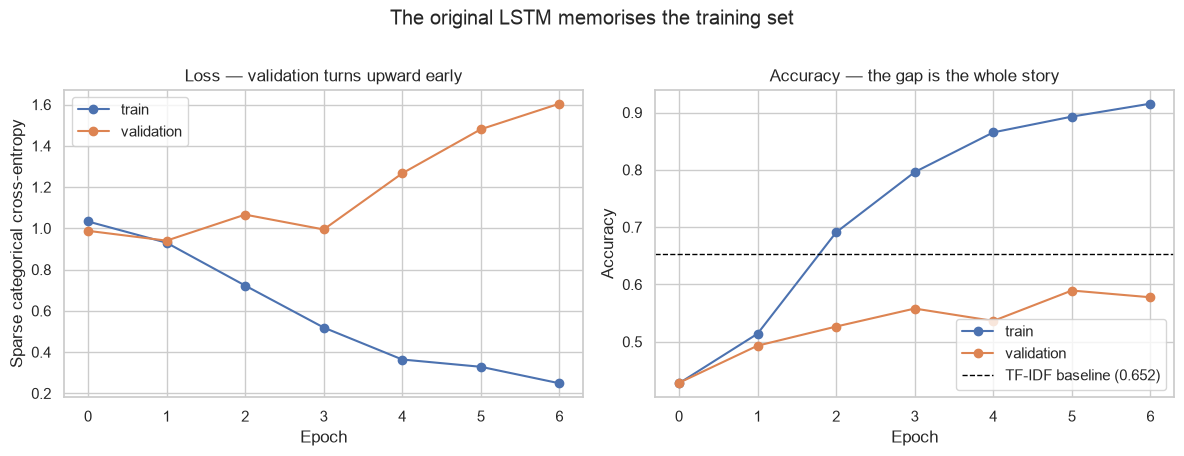

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["loss"], marker="o", label="train")
axes[0].plot(history.history["val_loss"], marker="o", label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy")
axes[0].set_title("Loss — validation turns upward early")
axes[0].legend()

axes[1].plot(history.history["accuracy"], marker="o", label="train")
axes[1].plot(history.history["val_accuracy"], marker="o", label="validation")
axes[1].axhline(bow_acc, color="black", linestyle="--", linewidth=1,
                label=f"TF-IDF baseline ({bow_acc:.3f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy — the gap is the whole story")
axes[1].legend(loc="lower right")

fig.suptitle("The original LSTM memorises the training set", y=1.01)
fig.tight_layout()
fig.savefig("../results/lstm_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
print(f"final training accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"gap:                       {history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:+.4f}")
print(f"\nvalidation loss by epoch:  "
      f"{[round(v, 3) for v in history.history['val_loss']]}")

final training accuracy:   0.9155
final validation accuracy: 0.5776
gap:                       +0.3379

validation loss by epoch:  [0.988, 0.94, 1.066, 0.994, 1.267, 1.48, 1.604]


Validation loss bottoms out at epoch two and trends upward from there, with one dip at
epoch four that a fixed seven-epoch schedule gives no way to distinguish from recovery.
Everything past
that point is the model memorising 2,035 tweets with 511,391 parameters — roughly 250
parameters per training example.

The original ran a fixed seven epochs with no validation split at all, so none of this
was visible. It reported the accuracy at epoch seven, which is well past the point where
the model started getting worse.

## 5. Two attempts to rescue it

It would be unfair to conclude "LSTMs don't work here" from one over-parameterised
configuration. Two variants, both given early stopping on validation loss:

1. **Smaller and regularised** — halve the embedding and hidden units, add spatial
   dropout and L2.
2. **Bidirectional** — read each tweet forwards and backwards. More capacity, but
   arguably a better inductive fit for sentiment, where the decisive phrase can be
   anywhere in the text.

In [11]:
def build_regularised(embed_dim=64, units=64, drop=0.5):
    model = keras.Sequential([
        keras.Input(shape=(1,), dtype="string"),
        vectorize,
        layers.Embedding(MAX_TOKENS, embed_dim, mask_zero=True),
        layers.SpatialDropout1D(drop),
        layers.LSTM(units, dropout=drop, recurrent_dropout=0.2,
                    kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dense(3, activation="softmax"),
    ], name="regularised_lstm")
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam",
                  metrics=["accuracy"])
    return model


def build_bidirectional(embed_dim=64, units=64, drop=0.5):
    model = keras.Sequential([
        keras.Input(shape=(1,), dtype="string"),
        vectorize,
        layers.Embedding(MAX_TOKENS, embed_dim, mask_zero=True),
        layers.SpatialDropout1D(drop),
        layers.Bidirectional(layers.LSTM(units, dropout=drop, recurrent_dropout=0.2)),
        layers.Dense(3, activation="softmax"),
    ], name="bidirectional_lstm")
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam",
                  metrics=["accuracy"])
    return model


stop_early = lambda: keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

for name, builder in [("LSTM (smaller + regularised)", build_regularised),
                      ("Bidirectional LSTM", build_bidirectional)]:
    model = builder()
    h = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2,
                  verbose=0, callbacks=[stop_early()])
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    rows.append({"model": name, "accuracy": acc, "parameters": model.count_params()})
    print(f"{name:32s} {acc:.4f}  ({len(h.history['loss'])} epochs, "
          f"{model.count_params():,} params)")

LSTM (smaller + regularised)     0.6220  (12 epochs, 161,219 params)


Bidirectional LSTM               0.6045  (9 epochs, 194,435 params)


In [12]:
comparison = pd.DataFrame(rows).set_index("model")
comparison["accuracy"] = comparison["accuracy"].round(4)
comparison

,accuracy,parameters
model,,
majority class,0.4298,0
TF-IDF + logistic regression,0.6523,35745
LSTM (original architecture),0.6148,511391
LSTM (smaller + regularised),0.6220,161219
Bidirectional LSTM,0.6045,194435


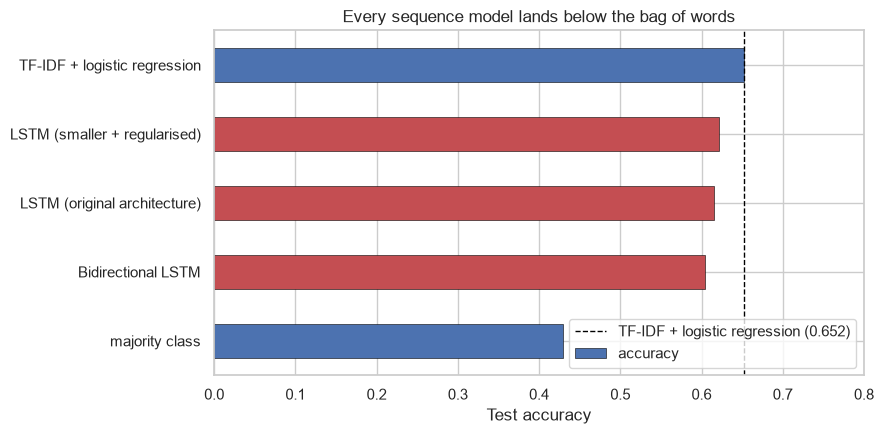

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = comparison.sort_values("accuracy")
colors = ["#c44e52" if "LSTM" in i else "#4c72b0" for i in order.index]
order["accuracy"].plot.barh(ax=ax, color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(bow_acc, color="black", linestyle="--", linewidth=1,
           label=f"TF-IDF + logistic regression ({bow_acc:.3f})")
ax.set_xlabel("Test accuracy")
ax.set_ylabel("")
ax.set_xlim(0, 0.8)
ax.set_title("Every sequence model lands below the bag of words")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("../results/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

Cutting capacity helps a little — the smaller regularised model is the best of the three
at 62.2%, on less than a third of the original's parameters. Going the other way does
not: the bidirectional model has the extra capacity and the better inductive story, and
it finishes last at 60.5%.

None of them clears the baseline. Three configurations spanning an order of magnitude in
capacity all land in a three-point band below TF-IDF, and the one that helped was the one
that removed parameters. That consistency is what makes the conclusion credible — this
is a data-volume ceiling, not one unlucky architecture.

## 6. Where the models disagree

Accuracy hides the shape of the errors. Both models are compared on the same test set.

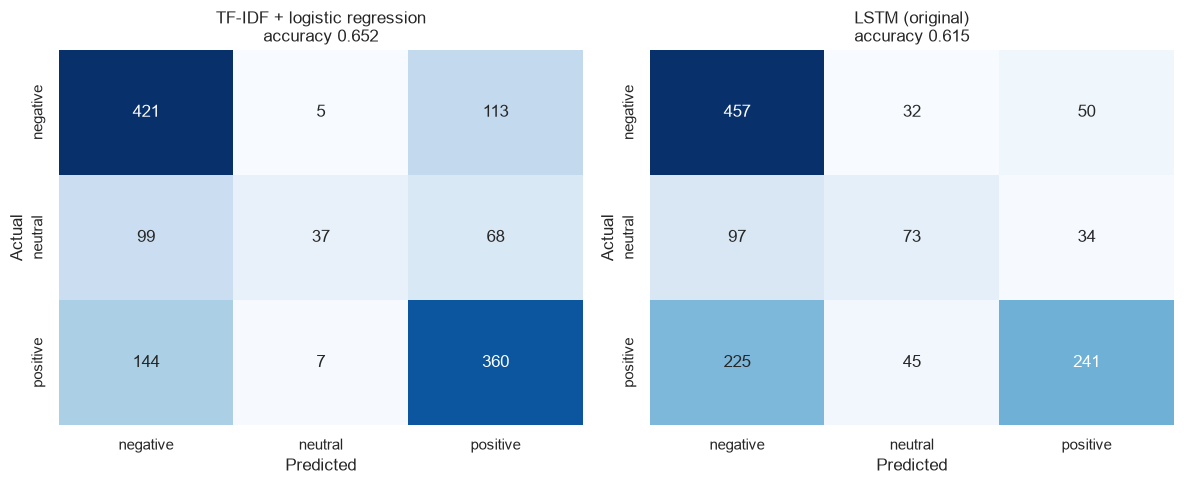

In [14]:
lstm_pred = lstm.predict(X_test, verbose=0).argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, preds) in zip(axes, [("TF-IDF + logistic regression", bow_pred),
                                     ("LSTM (original)", lstm_pred)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f"{title}\naccuracy {accuracy_score(y_test, preds):.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.tight_layout()
fig.savefig("../results/confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
print("TF-IDF + logistic regression")
print(classification_report(y_test, bow_pred, target_names=CLASSES, digits=3))
print("LSTM")
print(classification_report(y_test, lstm_pred, target_names=CLASSES, digits=3))

TF-IDF + logistic regression
              precision    recall  f1-score   support

    negative      0.634     0.781     0.700       539
     neutral      0.755     0.181     0.292       204
    positive      0.665     0.705     0.684       511

    accuracy                          0.652      1254
   macro avg      0.685     0.556     0.559      1254
weighted avg      0.667     0.652     0.627      1254

LSTM
              precision    recall  f1-score   support

    negative      0.587     0.848     0.693       539
     neutral      0.487     0.358     0.412       204
    positive      0.742     0.472     0.577       511

    accuracy                          0.615      1254
   macro avg      0.605     0.559     0.561      1254
weighted avg      0.634     0.615     0.600      1254



**`neutral` is the class both models struggle with**, and they fail differently. The
bag-of-words model is cautious — high precision, very low recall, predicting `neutral`
only when it is confident. The LSTM guesses `neutral` more freely and gets more of them,
at the cost of precision elsewhere.

Neutral is genuinely the hardest label. Negative and positive tweets carry
characteristic vocabulary; neutral ones are defined by the *absence* of it, which is a
much weaker signal for either model.

## 7. Saving, loading, and predicting on new text

The original notebook's most practical section. Because `TextVectorization` is a layer
inside the model, the saved artefact carries its own vocabulary — no separate tokeniser
pickle to keep in sync, and raw strings can be passed straight in.

In [16]:
lstm.save("tweet_sentiment_lstm.keras")
reloaded = keras.models.load_model("tweet_sentiment_lstm.keras")

reload_acc = reloaded.evaluate(X_test, y_test, verbose=0)[1]
print(f"accuracy before saving: {lstm_acc:.4f}")
print(f"accuracy after loading: {reload_acc:.4f}")
assert np.isclose(lstm_acc, reload_acc), "reloaded model must match"

accuracy before saving: 0.6148
accuracy after loading: 0.6148


In [17]:
new_tweets = [
    "supermarkets are completely empty and no one knows when stock returns",
    "huge thanks to the delivery drivers keeping everyone going right now",
    "the store opens at 9am on weekdays and 10am on sundays",
    "not happy with how this is being handled at all",
]
cleaned = np.array([clean(t) for t in new_tweets], dtype=object)  # object, as above
probs = reloaded.predict(cleaned, verbose=0)

pd.DataFrame({
    "tweet": [t[:60] + "…" for t in new_tweets],
    "prediction": [CLASSES[i] for i in probs.argmax(axis=1)],
    "confidence": probs.max(axis=1).round(3),
})

,tweet,prediction,confidence
0,supermarkets are completely empty and no one k...,negative,0.992
1,huge thanks to the delivery drivers keeping ev...,positive,0.830
2,the store opens at 9am on weekdays and 10am on...,neutral,0.766
3,not happy with how this is being handled at all…,negative,0.980


The last example is the interesting one — `"not happy"` is exactly the construction a
sequence model should handle and a unigram bag of words cannot. This model gets it right,
and confidently.

That is worth exactly as much as one example is worth. The architecture can represent
negation, and here it did; across the 1,254-tweet test set it still finishes three and a
half points below a model that cannot represent negation at all. A single well-chosen
demonstration is the easiest way to overstate a model, which is why the table above is
the result and this cell is an illustration.

## Findings

| model | test accuracy | parameters |
|---|---|---|
| Majority class | 43.0% | 0 |
| **TF-IDF + logistic regression** | **65.2%** | 35,745 |
| LSTM (original architecture) | 61.5% | 511,391 |
| LSTM (smaller + regularised) | 62.2% | 161,219 |
| Bidirectional LSTM | 60.5% | 194,435 |

1. **Every sequence model loses to the bag of words.** Three configurations spanning an
   order of magnitude in capacity all land in a three-point band below TF-IDF with
   bigrams — and the best of them is the one with the fewest parameters. The consistency
   is what makes it credible.
2. **The original LSTM memorises.** 91.6% training accuracy against 57.8% validation,
   with validation loss trending upward after epoch two — 511,391 parameters against 2,035
   training tweets, about 250 parameters per example.
3. **The original had no validation split**, so none of that was visible. It reported
   accuracy at a fixed seventh epoch, well past the point the model began getting worse.
4. **`neutral` is the hardest class for both models**, and they fail differently: the
   linear model is cautious and precise, the LSTM guesses more freely.
5. **Word order didn't pay for itself here** — but the constraint is the corpus size, not
   the idea.

## Limitations

- **3,798 tweets is small.** The full Coronavirus Tweets dataset has roughly 41,000
  training rows; this repository ships only the test split. Ten times the data is the
  single change most likely to reverse the conclusion.
- **No pretrained embeddings.** The embedding layer is learned from scratch on 2,035
  tweets. GloVe or a transformer encoder would bring outside language knowledge and is
  the standard fix for exactly this situation.
- **Single run per configuration.** Neural results vary with initialisation; the seed is
  pinned but treat differences under a point or so as noise.
- **The labels are annotator judgements** on short, ambiguous text. Some fraction of the
  remaining error is disagreement no model can resolve.
- **Collapsing five classes to three** discards intensity information the original data
  carried.
- The test set is used to compare five models, so the reported figures are mildly
  optimistic as estimates of performance on genuinely new data.

## Next step

Fine-tune a small pretrained transformer on the same split. If a model with outside
language knowledge clears 65.2% comfortably, that confirms the ceiling here is the
corpus size rather than the task.

## Outputs

- `results/lstm_training_curves.png`
- `results/model_comparison.png`
- `results/confusion_matrices.png`
- `tweet_sentiment_lstm.keras` — saved model (gitignored)